# 04 — Baseline XGBoost Training

Train a multi-class XGBoost classifier on our 5 test stocks using the 21 technical indicator features and signal labels.

**Pipeline:** Fetch data → compute features → compute labels → time-based train/test split → train XGBoost → evaluate with weighted F1, confusion matrix, feature importance.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## 1. Reusable Functions (from notebooks 02 & 03)

In [2]:
HORIZONS = {"3m": 63, "6m": 126, "1y": 252}

THRESHOLDS = {
    "3m": (-8, -3, 3, 8),
    "6m": (-12, -4, 5, 12),
    "1y": (-15, -5, 8, 20),
}

SIGNAL_LABELS = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]

FEATURE_COLS = [
    "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm",
    "RSI", "Stoch_K", "Stoch_D", "ROC",
    "BB_Position", "BB_Width", "ATR_Pct",
    "OBV_Norm", "Vol_SMA_Ratio",
    "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m",
]


def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all technical indicators on a DataFrame with OHLCV columns.
    
    All features are relative (ratios, percentages, bounded scales) so they
    generalize across stocks at different price levels.
    """
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # --- Trend (ratios around 1.0) ---
    sma_50 = df["Close"].rolling(window=50).mean()
    sma_200 = df["Close"].rolling(window=200).mean()
    ema_20 = df["Close"].ewm(span=20, adjust=False).mean()
    df["Price_SMA50_Ratio"] = df["Close"] / sma_50
    df["Price_SMA200_Ratio"] = df["Close"] / sma_200
    df["Price_EMA20_Ratio"] = df["Close"] / ema_20

    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_signal_raw = macd_raw.ewm(span=9, adjust=False).mean()
    df["MACD_Norm"] = macd_raw / df["Close"] * 100
    df["MACD_Signal_Norm"] = macd_signal_raw / df["Close"] * 100
    df["MACD_Hist_Norm"] = df["MACD_Norm"] - df["MACD_Signal_Norm"]

    # --- Momentum ---
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))

    low_14 = df["Low"].rolling(window=14).min()
    high_14 = df["High"].rolling(window=14).max()
    df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
    df["Stoch_D"] = df["Stoch_K"].rolling(window=3).mean()
    df["ROC"] = df["Close"].pct_change(periods=21) * 100

    # --- Volatility (relative) ---
    bb_sma = df["Close"].rolling(window=20).mean()
    bb_std = df["Close"].rolling(window=20).std()
    bb_upper = bb_sma + 2 * bb_std
    bb_lower = bb_sma - 2 * bb_std
    df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)
    df["BB_Width"] = (bb_upper - bb_lower) / bb_sma

    high_low = df["High"] - df["Low"]
    high_close = (df["High"] - df["Close"].shift(1)).abs()
    low_close = (df["Low"] - df["Close"].shift(1)).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df["ATR_Pct"] = true_range.rolling(window=14).mean() / df["Close"] * 100

    # --- Volume (relative) ---
    obv_sign = np.sign(df["Close"].diff())
    obv = (obv_sign * df["Volume"]).cumsum()
    df["OBV_Norm"] = obv.diff(21) / df["Volume"].rolling(21).mean()
    df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(window=20).mean()

    # --- Price-derived (percentages) ---
    high_252 = df["High"].rolling(window=252).max()
    low_252 = df["Low"].rolling(window=252).min()
    df["Dist_52w_High"] = (df["Close"] - high_252) / high_252 * 100
    df["Dist_52w_Low"] = (df["Close"] - low_252) / low_252 * 100
    df["Return_1m"] = df["Close"].pct_change(periods=21) * 100
    df["Return_3m"] = df["Close"].pct_change(periods=63) * 100

    return df


def compute_future_returns(close: pd.Series, horizon_days: int) -> pd.Series:
    return (close.shift(-horizon_days) / close - 1) * 100


def assign_signal(returns: pd.Series, thresholds: tuple) -> pd.Series:
    ss, s, b, sb = thresholds
    conditions = [
        returns < ss,
        (returns >= ss) & (returns < s),
        (returns >= s) & (returns < b),
        (returns >= b) & (returns < sb),
        returns >= sb,
    ]
    return pd.Series(
        np.select(conditions, SIGNAL_LABELS, default=""),
        index=returns.index,
    ).replace("", np.nan)

print("Functions loaded.")

Functions loaded.


## 2. Build Dataset

Fetch data, compute features and labels for all test stocks, combine into one dataset.

In [3]:
test_tickers = ["AAPL", "MSFT", "JPM", "JNJ", "XOM"]
data = yf.download(test_tickers, period="5y", group_by="ticker", auto_adjust=True)

# We'll train one model per horizon. Start with 3m as the baseline.
HORIZON = "3m"
horizon_days = HORIZONS[HORIZON]
thresholds = THRESHOLDS[HORIZON]

datasets = []
for ticker in test_tickers:
    df = data[ticker].copy()
    df = compute_features(df)
    
    future_ret = compute_future_returns(df["Close"], horizon_days)
    df["Signal"] = assign_signal(future_ret, thresholds)
    df["Ticker"] = ticker
    
    # Drop rows with NaN in features or label
    df_clean = df.dropna(subset=FEATURE_COLS + ["Signal"])
    datasets.append(df_clean)

full_df = pd.concat(datasets)
print(f"Horizon: {HORIZON}")
print(f"Total samples: {len(full_df)}")
print(f"Tickers: {full_df['Ticker'].nunique()}")
print(f"Date range: {full_df.index.min().date()} to {full_df.index.max().date()}")
print(f"\nClass distribution:")
print(full_df["Signal"].value_counts().reindex(SIGNAL_LABELS).to_string())

[                       0%                       ]

[*******************   40%                       ]  2 of 5 completed

[**********************60%****                   ]  3 of 5 completed

[*********************100%***********************]  5 of 5 completed

Horizon: 3m
Total samples: 4705
Tickers: 5
Date range: 2022-03-22 to 2025-12-18

Class distribution:
Signal
Strong Sell     588
Sell            645
Hold            969
Buy             815
Strong Buy     1688


## 3. Time-Based Train/Test Split

Split by date, NOT randomly. Using random splits on time series causes data leakage — the model would "see" future patterns during training. We use the first 80% of dates for training, last 20% for testing.

In [4]:
# Sort by date and find the 80% cutoff
all_dates = full_df.index.unique().sort_values()
split_idx = int(len(all_dates) * 0.8)
split_date = all_dates[split_idx]

train_df = full_df[full_df.index < split_date]
test_df = full_df[full_df.index >= split_date]

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

# Encode labels to integers (0-4)
le = LabelEncoder()
le.fit(SIGNAL_LABELS)
y_train = le.transform(train_df["Signal"])
y_test = le.transform(test_df["Signal"])

print(f"Split date: {split_date.date()}")
print(f"Train: {len(X_train)} samples ({train_df.index.min().date()} to {train_df.index.max().date()})")
print(f"Test:  {len(X_test)} samples ({test_df.index.min().date()} to {test_df.index.max().date()})")
print(f"\nTrain class distribution:")
print(pd.Series(y_train).map(dict(enumerate(SIGNAL_LABELS))).value_counts().reindex(SIGNAL_LABELS).to_string())
print(f"\nTest class distribution:")
print(pd.Series(y_test).map(dict(enumerate(SIGNAL_LABELS))).value_counts().reindex(SIGNAL_LABELS).to_string())

Split date: 2025-03-21
Train: 3760 samples (2022-03-22 to 2025-03-20)
Test:  945 samples (2025-03-21 to 2025-12-18)

Train class distribution:
Strong Sell     657
Sell            825
Hold            567
Buy            1195
Strong Buy      516

Test class distribution:
Strong Sell    158
Sell           144
Hold            78
Buy            493
Strong Buy      72


## 4. Train XGBoost

In [5]:
# Compute class weights to handle imbalance
from collections import Counter

class_counts = Counter(y_train)
total = len(y_train)
n_classes = len(SIGNAL_LABELS)
class_weights = {cls: total / (n_classes * count) for cls, count in class_counts.items()}
sample_weights = np.array([class_weights[y] for y in y_train])

print("Class weights:", {SIGNAL_LABELS[k]: f"{v:.2f}" for k, v in class_weights.items()})

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, sample_weight=sample_weights)
print("\nModel trained.")

Class weights: {'Strong Buy': '1.46', 'Hold': '1.33', 'Sell': '0.91', 'Strong Sell': '1.14', 'Buy': '0.63'}



Model trained.


## 5. Evaluate

In [6]:
y_pred = model.predict(X_test)

# Primary metrics
w_f1 = f1_score(y_test, y_pred, average="weighted")
acc = accuracy_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"=== {HORIZON} Horizon Results ===")
print(f"Weighted F1:  {w_f1:.4f}")
print(f"Accuracy:     {acc:.4f}")
print(f"MAE (class):  {mae:.4f}  (0 = perfect, 4 = worst possible)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=SIGNAL_LABELS, zero_division=0))

=== 3m Horizon Results ===
Weighted F1:  0.2483
Accuracy:     0.2148
MAE (class):  1.3524  (0 = perfect, 4 = worst possible)

Classification Report:
              precision    recall  f1-score   support

 Strong Sell       0.23      0.15      0.18       158
        Sell       0.17      0.22      0.19       144
        Hold       0.05      0.14      0.08        78
         Buy       0.48      0.27      0.35       493
  Strong Buy       0.02      0.06      0.03        72

    accuracy                           0.21       945
   macro avg       0.19      0.17      0.17       945
weighted avg       0.32      0.21      0.25       945



## 6. Confusion Matrix

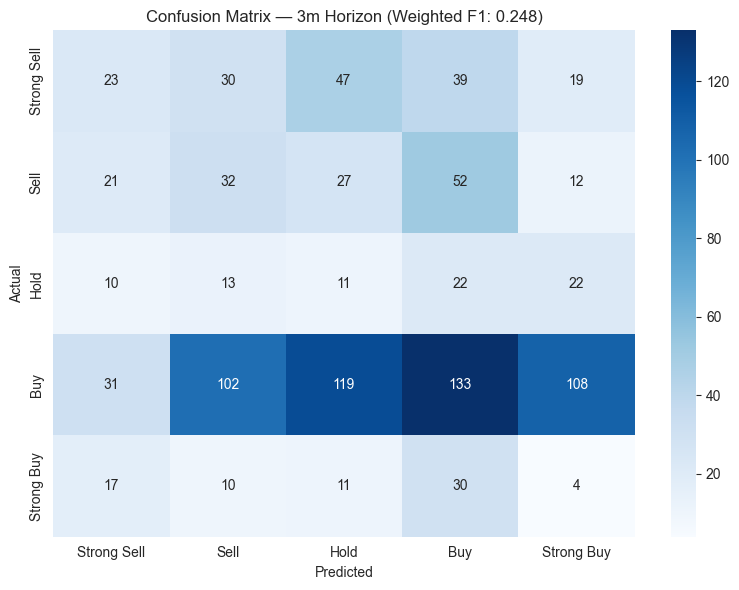

In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {HORIZON} Horizon (Weighted F1: {w_f1:.3f})")
plt.tight_layout()
plt.show()

## 7. Feature Importance

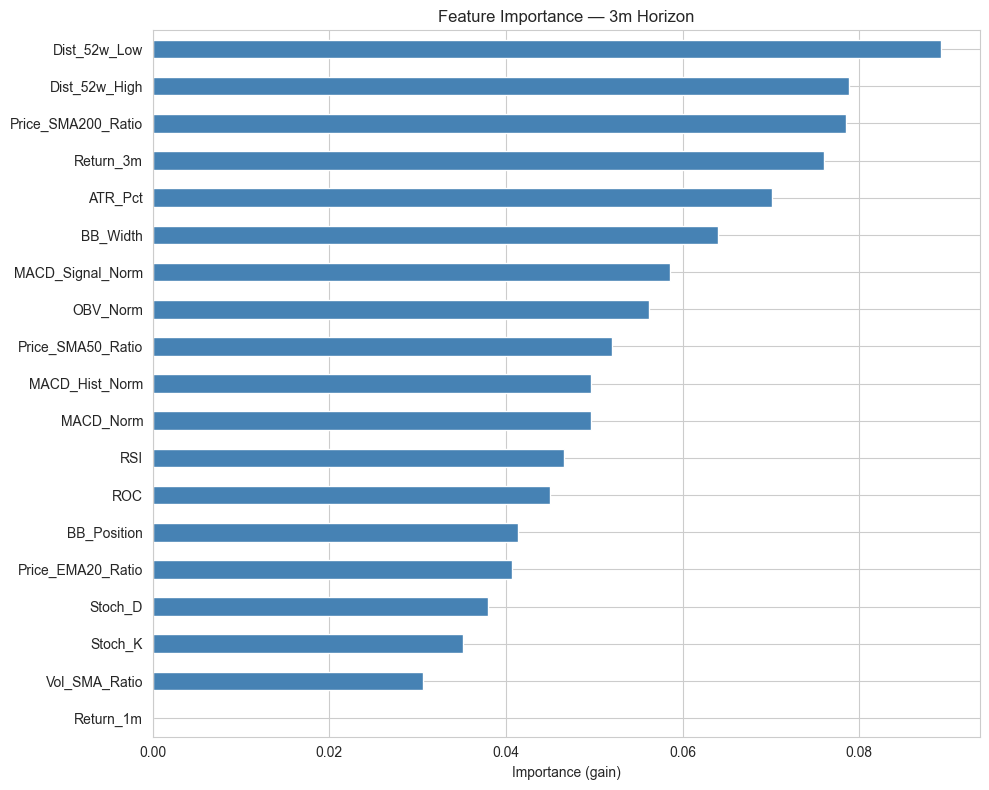


Top 5 features:
  Dist_52w_Low: 0.0892
  Dist_52w_High: 0.0789
  Price_SMA200_Ratio: 0.0785
  Return_3m: 0.0760
  ATR_Pct: 0.0701


In [8]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Feature Importance — {HORIZON} Horizon")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for feat, imp in importances.tail(5).iloc[::-1].items():
    print(f"  {feat}: {imp:.4f}")